In [1]:
from os.path import isdir

from helpers.helpers import get_checkpoint_name_and_checkpoint_path
from helpers.embeddings import load_embeddings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scienceplots
plt.style.use('science')

# FONTS
import sys
from os.path import abspath
source_path = abspath('..')
if not source_path in sys.path:
    sys.path.append(source_path)
from font import SETTINGS
for key in SETTINGS:
    plt.rc(key, **SETTINGS[key])

nanogpt_path = abspath('../nanoGPT')
if not nanogpt_path in sys.path:
    sys.path.append(nanogpt_path)

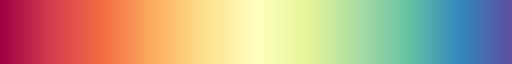

In [2]:
_cmap = plt.get_cmap('Spectral')
_cmap

In [3]:
cmap = _cmap(np.linspace(1, 0, 10)) # start with blue, end with red
len(cmap)

10

In [4]:
COLOR = plt.rcParams['axes.prop_cycle']
COLOR = [v for elem in list(COLOR) for _, v in elem.items()]
COLOR

['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']

In [5]:
FIGURE_FORMAT = 'pdf'
# FIGURE_FORMAT = 'png'

In [6]:
CHECKPOINT_DIRECTORY = '../checkpoints'
assert isdir(CHECKPOINT_DIRECTORY)

In [7]:
POSITIONS = ['output']

# 0. Get Checkpoint

In [8]:
N = [
    '4', 
    '4', '4', '4', '4', '4', '4', '4',
    '6', '6', '6', '6', '6', '6', '6',
    '8', '8', '8', '8', '8', '8', '8',
    'A', 'A', 'A', 'A', 'A', 'A', 'A',
    'C', 'C', 'C', 'C', 'C', 'C', 'C',
]
D = 0
VARIANT = [
    'A', 
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
    'a', 'a', 'a', 'a', 'a', 'a', 'a',
]
GAMMA = '0e+00'
LR = [
    'lr10-', 
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
    'lr3-', 'lr10-', 'lr30-', 'lr100-', 'lr300-', 'lr1000-', 'lr3000-',
]
CHECKPOINT = 'ckpt_100000'

In [9]:
N0 = N[0]
VARIANT0 = VARIANT[0]
LR0 = LR[0]

In [10]:
if VARIANT0 == 'A':
    limnorm = [-2, 5]
elif VARIANT0 == 'a':
    limnorm = [-20, 100]
else:
    raise Exception()

In [11]:
checkpoint_names, checkpoint_paths = {}, {}

for i, (n, variant, lr) in enumerate(zip(N, VARIANT, LR)):
    checkpoint_names[(n,variant,lr)], checkpoint_paths[(n,variant,lr)] = get_checkpoint_name_and_checkpoint_path(
        CHECKPOINT_DIRECTORY, n, D, variant, lr, GAMMA, CHECKPOINT
    )
    if i == 0:
        KEY0 = (n, variant, lr)
KEYS = list(checkpoint_names.keys())

# checkpoint_names, checkpoint_paths, KEY0, KEYS

# 1. Load Embeddings

### a. Embeddings

In [12]:
OVERWRITE = False

In [13]:
embeddings = {
    k: load_embeddings(
        checkpoint_paths[k], 
        checkpoint_names[k], 
        positions=POSITIONS, 
        overwrite=OVERWRITE,
    )
    for k in KEYS
}

> loaded embeddings for wor40A-16M-13p1B-100k-bs64-lr10-baseline-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr3-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr10-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr30-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr100-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr300-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded embeddings for wor40a-16M-13p1B-100k-bs64-lr1000-baselinewt-g0e+00-s1
.. position = output, embeddings[position].shape = (50304, 224)
> loaded emb

# 2. Analysis: Components Parallel & Perpendicular To Mean Embedding

### a. Embeddings

In [14]:
embeddings[KEY0].keys()

dict_keys(['output'])

In [15]:
E = {k: embeddings[k]['output'] for k in KEYS}
E[KEY0].shape

(50304, 224)

In [16]:
mu = {k: np.mean(E[k], axis=0, keepdims=True).T for k in KEYS}
musq = {k: (mu[k].T @ mu[k])[0, 0] for k in KEYS}
musq[KEY0]

np.float32(4.894086)

### b. 1D histogram: dot products unnormalized

In [17]:
dots = {k: (E[k] @ mu[k])[:, 0] for k in KEYS}
dots[KEY0].shape

(50304,)

In [18]:
np.min(dots[KEY0]), np.max(dots[KEY0])

(np.float32(-2.9141207), np.float32(9.550041))

In [19]:
B_plus = {k: np.max(dots[k]) - musq[k] for k in KEYS}
B_plus[KEY0]

np.float32(4.6559553)

In [20]:
B_minus = {k: musq[k] - np.min(dots[k]) for k in KEYS}
- B_minus[KEY0]

np.float32(-7.8082066)

In [21]:
def plot_histogram(_dots, _musq, _B_plus, _B_minus, save_as='', hat=False):

    COLOR_ZERO = COLOR[-2]
    COLOR_BOUND = COLOR[1]
    COLOR_HIST = COLOR[3]
    COLOR_MEAN = COLOR[4]
    
    _, ax = plt.subplots(1, 1, figsize=(4,4))
    ax = [ax, None]
    
    df = pd.DataFrame.from_dict({'dot product': _dots})
    _ = sns.histplot(x=df['dot product'], ax=ax[0], color=COLOR_HIST, edgecolor=COLOR_HIST)
    xlabel = r'$e_i \cdot \hat \mu$' if hat is True else r'$e_i \cdot \mu$'
    _ = ax[0].set_xlabel(xlabel)
    _ = ax[0].plot([0, 0], [0, 2000], marker='', linestyle=':', color=COLOR_ZERO)
    _ = ax[0].plot([_musq, _musq], [0, 2000], marker='', linestyle='--', linewidth=2, color=COLOR_MEAN)
    _ = ax[0].plot([_musq+_B_plus, _musq+_B_plus], [0, 2000], marker='', linestyle='--', linewidth=2, color=COLOR_BOUND)
    _ = ax[0].plot([_musq-_B_minus, _musq-_B_minus], [0, 2000], marker='', linestyle='--', linewidth=2, color=COLOR_BOUND)
    xlim = ax[0].get_xlim()
    xlim_new = max(xlim)
    _ = ax[0].set_xlim([-xlim_new, xlim_new])
    
    # print
    if hat is True:
        print(f'||mu|| = {_musq:.2f}')
        print(f'B_plus = {_B_plus:.2f}')
        print(f'=> ||mu|| + B_plus = {_musq+_B_plus:.2f}')
        print(f'B_minus = {_B_minus:.2f}')
        _B_ratio = np.max((_B_minus, _B_plus)) / np.max((_B_minus - _musq, _B_plus + _musq))
        print(f'=> B_ratio = {_B_ratio:.2f}')
    else:
        print(f'mu**2 = {_musq:.2f}')
        print(f'B_plus = {_B_plus:.2f}')
        print(f'=> (mean_embedding)**2 + B_plus = {_musq+_B_plus:.2f}')
        print(f'B_minus = {_B_minus:.2f}')
        _B_ratio = np.max((_B_minus, _B_plus)) / np.max((_B_minus - _musq, _B_plus + _musq))
        print(f'=> B_ratio = {_B_ratio:.2f}')

    mulabel = r'$\| \mu \|$' if hat is True else r'$\| \mu \|^2$'
    shift_B_plus = 1 if hat is True else 2
    shift_B_minus = 4 if hat is True else 8.5
    shift_musq = 0.25 if hat is True else 0.5
    _ = ax[0].annotate("", xytext=(_musq, 1800), xy=(_musq + _B_plus, 1800), arrowprops=dict(arrowstyle="->", linewidth=2, color=COLOR_BOUND))
    _ = ax[0].annotate("", xytext=(_musq, 1800), xy=(_musq - _B_minus, 1800), arrowprops=dict(arrowstyle="->", linewidth=2, color=COLOR_BOUND))
    _ = ax[0].text(_B_plus + shift_B_plus, 1670, r'$B_+$', color=COLOR_BOUND)
    _ = ax[0].text(-_B_minus + shift_B_minus, 1670, r'$B_-$', color=COLOR_BOUND)
    _ = ax[0].text(_musq + shift_musq, 1890, mulabel, color=COLOR_MEAN)

    if len(save_as):
        assert save_as.endswith('.pdf') or save_as.endswith('.png')
        fig_path = f'figs/{save_as}'
        plt.savefig(fig_path, format=save_as[-3:], bbox_inches='tight')
        print(f'> saved as {fig_path}')

mu**2 = 4.89
B_plus = 4.66
=> (mean_embedding)**2 + B_plus = 9.55
B_minus = 7.81
=> B_ratio = 0.82
> saved as figs/dot_product_histogram_40A-lr10--gamma0e+00-ckpt_100000.pdf


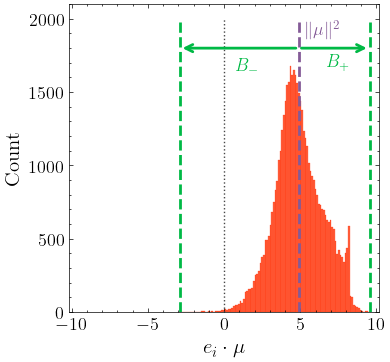

In [22]:
plot_histogram(
    dots[KEY0], 
    musq[KEY0], 
    B_plus[KEY0], 
    B_minus[KEY0], 
    save_as=f'dot_product_histogram_{N0}{D}{VARIANT0}-{LR0}-gamma{GAMMA}-{CHECKPOINT}.{FIGURE_FORMAT}',
)

### b'. 1D histogram: dot products normalized

In [23]:
muhat = {k: mu[k] / np.sqrt(musq[k]) for k in KEYS}
np.linalg.norm(muhat[KEY0]), muhat[KEY0].shape

(np.float32(0.99999994), (224, 1))

In [24]:
dotshat = {k: (E[k] @ muhat[k])[:, 0] for k in KEYS}
dotshat[KEY0].shape

(50304,)

In [25]:
np.min(dotshat[KEY0]), np.max(dotshat[KEY0])

(np.float32(-1.3172606), np.float32(4.316875))

In [26]:
B_plus_hat = {k: np.max(dotshat[k]) - np.sqrt(musq[k]) for k in KEYS}
B_plus_hat[KEY0]

np.float32(2.1046169)

In [27]:
B_minus_hat = {k: np.sqrt(musq[k]) - np.min(dotshat[k]) for k in KEYS}
- B_minus_hat[KEY0]

np.float32(-3.5295186)

||mu|| = 2.21
B_plus = 2.10
=> ||mu|| + B_plus = 4.32
B_minus = 3.53
=> B_ratio = 0.82
> saved as figs/dothat_product_histogram_40A-lr10--gamma0e+00-ckpt_100000.pdf


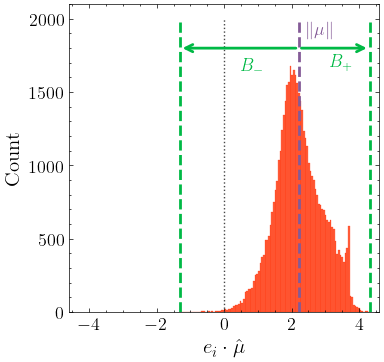

In [28]:
plot_histogram(
    dotshat[KEY0], 
    np.sqrt(musq[KEY0]), 
    B_plus_hat[KEY0], 
    B_minus_hat[KEY0], 
    save_as=f'dothat_product_histogram_{N0}{D}{VARIANT0}-{LR0}-gamma{GAMMA}-{CHECKPOINT}.{FIGURE_FORMAT}',
    hat=True,
)

### c. 2D histogram: dot products normalized & perpendicular norm

In [29]:
E_para = {k: (E[k] @ muhat[k]) @ muhat[k].T for k in KEYS}
E_para[KEY0].shape

(50304, 224)

In [30]:
E_perp = {k: E[k] - E_para[k] for k in KEYS}
E_perp[KEY0].shape

(50304, 224)

In [31]:
E_para_norm = {k: np.linalg.norm(E_para[k], axis=1, keepdims=False) for k in KEYS}
E_para_norm[KEY0].shape

(50304,)

In [32]:
E_perp_norm = {k: np.linalg.norm(E_perp[k], axis=1, keepdims=False) for k in KEYS}
E_perp_norm[KEY0].shape

(50304,)

In [33]:
df = {
    k: pd.DataFrame(
        data=[dotshat[k], E_para_norm[k], E_perp_norm[k]], 
        index=[r'$e_i \cdot \hat \mu$', r'$\| e_i^\parallel \|$', r'$\| e_i^\perp \|$']
    ).T
    for k in KEYS
}
df[KEY0].head()

,$e_i \cdot \hat \mu$,$\| e_i^\parallel \|$,$\| e_i^\perp \|$
0,-0.019283,0.019283,1.341117
1,0.494869,0.494869,1.499325
2,1.385371,1.385371,0.835508
3,1.467429,1.467429,0.880759
4,1.090847,1.090847,1.092326


In [34]:
df[KEY0].describe()

,$e_i \cdot \hat \mu$,$\| e_i^\parallel \|$,$\| e_i^\perp \|$
count,50304.000000,50304.000000,50304.000000
mean,2.212248,2.213910,0.960593
std,0.712780,0.707600,0.305408
min,-1.317261,0.001212,0.417083
25%,1.762332,1.762331,0.746301
50%,2.158328,2.158328,0.890111
75%,2.677652,2.677652,1.094053
max,4.316875,4.316875,2.961185


In [35]:
def plot_jointplot(_data, _x, _y, _xlim, _ylim, _munorm, height=5, title=''):
    lim_lower = np.floor(min(np.min(_data[_x]), np.min(_data[_y])))
    if lim_lower > 0:
        lim_lower = 0
    lim_upper = np.ceil(max(np.max(_data[_x]), np.max(_data[_y])))
    lim = [lim_lower, lim_upper]
    
    _data['below'] = _data[_x].map(lambda x: x < _munorm / 2)
    _data[r'$\| e_i \|$'] = np.sqrt(_data[_x]**2 + _data[_y]**2)
    _data[r'$\| e_i^\star \|$'] = np.sqrt((_data[_x] - _munorm)**2 + _data[_y]**2)
    
    _data_below = _data[_data['below'] == True]
    _data_above = _data[_data['below'] == False]
    
    max_above_index = _data_above[r'$\| e_i \|$'].argmax()
    max_above_x = _data_above[r'$\| e_i^\parallel \|$'].iloc[max_above_index]
    max_above_y = _data_above[r'$\| e_i^\perp \|$'].iloc[max_above_index]
    max_above_ratio = np.sqrt(max_above_x**2+max_above_y**2)
    print(f'above: index = {max_above_index:5d}, ({max_above_x:.2f}**2 + {max_above_y:.2f}**2)**1/2 = {np.sqrt(max_above_x**2+max_above_y**2):.2f}')

    max_below_index = _data_below[r'$\| e_i^\star \|$'].argmax()
    max_below_x = _data_below[r'$\| e_i^\parallel \|$'].iloc[max_below_index] + _munorm
    max_below_y = _data_below[r'$\| e_i^\perp \|$'].iloc[max_below_index]
    max_below_ratio = np.sqrt(max_below_x**2+max_below_y**2)
    print(f'below: index = {max_below_index:5d}, ({max_below_x:.2f}**2 + {max_below_y:.2f}**2)**1/2 = {max_below_ratio:.2f}')
    print(f'=> ratio_para = {max_below_x/max_above_x:.2f} | ratio_perp = {max_below_y/max_above_y:.2f} => ratio_all = {max_below_ratio/max_above_ratio:.2f}')
    print()


    plot = sns.jointplot(data=_data, x=_x, y=_y, hue='below', xlim=lim, ylim=lim, height=height, kind='scatter', legend=False)
    plot.ax_joint.axvline(x=_munorm, linestyle='--', linewidth=1, color=COLOR[5])
    # plot.ax_joint.axvline(x=_munorm/2, linestyle='--', linewidth=2, color=COLOR[4])
    plot.ax_joint.axvline(x=0, linestyle='--', linewidth=1, color=COLOR[5])
    if len(title):
        plot.ax_joint.set_title(title, pad=45)

    sns.scatterplot(data=_data_below.iloc[[max_below_index]], x=_x, y=_y, color='r', ax=plot.ax_joint)
    sns.scatterplot(data=_data_above.iloc[[max_above_index]], x=_x, y=_y, color='r', ax=plot.ax_joint)

def nicekey(key):
    return f'{key[0]}{key[1]}-{key[2][:-1]}'

above: index = 35802, (4.22**2 + 2.19**2)**1/2 = 4.76
below: index =    10, (3.50**2 + 2.15**2)**1/2 = 4.11
=> ratio_para = 0.83 | ratio_perp = 0.98 => ratio_all = 0.86



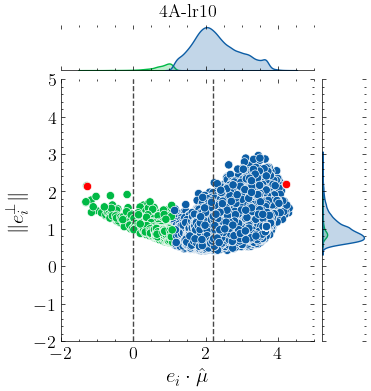

In [36]:
plot_jointplot(
    _data=df[KEY0], 
    _x=r'$e_i \cdot \hat \mu$', 
    _y=r'$\| e_i^\perp \|$', 
    _xlim=limnorm, 
    _ylim=limnorm, 
    _munorm=np.sqrt(musq[KEY0]),
    height=4,
    title=nicekey(KEY0),
)

### c'. 2D histogram: dot products normalized & perpendicular norm (all)

above: index = 33312, (1.98**2 + 1.00**2)**1/2 = 2.22
below: index =    10, (2.22**2 + 1.34**2)**1/2 = 2.60
=> ratio_para = 1.12 | ratio_perp = 1.34 => ratio_all = 1.17

above: index = 33300, (2.81**2 + 3.17**2)**1/2 = 4.24
below: index =     9, (2.85**2 + 2.24**2)**1/2 = 3.62
=> ratio_para = 1.01 | ratio_perp = 0.71 => ratio_all = 0.85

above: index = 43181, (9.02**2 + 8.80**2)**1/2 = 12.60
below: index =    10, (9.57**2 + 5.57**2)**1/2 = 11.07
=> ratio_para = 1.06 | ratio_perp = 0.63 => ratio_all = 0.88

above: index = 29083, (35.85**2 + 18.38**2)**1/2 = 40.29
below: index =    79, (27.77**2 + 17.07**2)**1/2 = 32.60
=> ratio_para = 0.77 | ratio_perp = 0.93 => ratio_all = 0.81



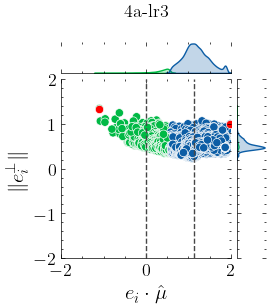

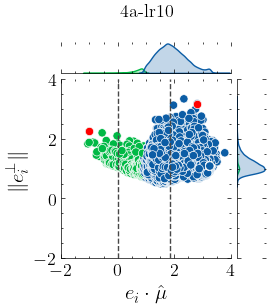

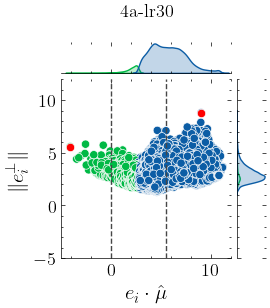

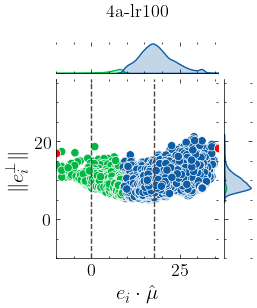

In [37]:
# model_size = 4

for k in KEYS[1:5]:
    plot_jointplot(
        _data=df[k], 
        _x=r'$e_i \cdot \hat \mu$', 
        _y=r'$\| e_i^\perp \|$', 
        _xlim=limnorm, 
        _ylim=limnorm, 
        _munorm=np.sqrt(musq[k]),
        height=3,
        title=nicekey(k),
    )

above: index =  3017, (96.36**2 + 53.74**2)**1/2 = 110.33
below: index =     9, (68.60**2 + 51.88**2)**1/2 = 86.01
=> ratio_para = 0.71 | ratio_perp = 0.97 => ratio_all = 0.78

above: index = 47882, (302.79**2 + 183.10**2)**1/2 = 353.85
below: index =    49, (186.47**2 + 152.03**2)**1/2 = 240.59
=> ratio_para = 0.62 | ratio_perp = 0.83 => ratio_all = 0.68

above: index = 43160, (702.32**2 + 435.13**2)**1/2 = 826.19
below: index =    70, (409.21**2 + 427.24**2)**1/2 = 591.60
=> ratio_para = 0.58 | ratio_perp = 0.98 => ratio_all = 0.72

above: index = 42522, (1.94**2 + 0.96**2)**1/2 = 2.17
below: index =    10, (2.13**2 + 1.29**2)**1/2 = 2.48
=> ratio_para = 1.10 | ratio_perp = 1.34 => ratio_all = 1.15



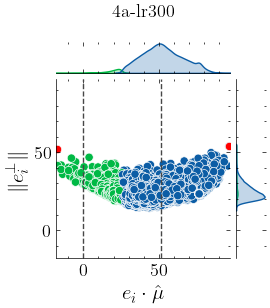

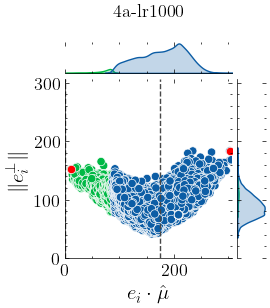

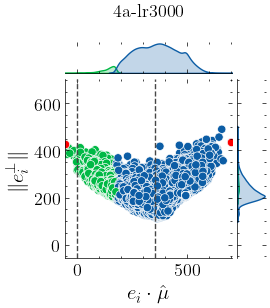

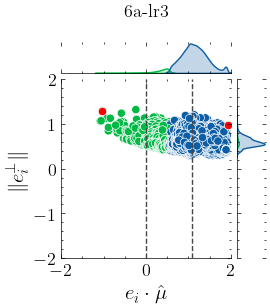

In [38]:
# model_size = 6

for k in KEYS[5:9]:
    plot_jointplot(
        _data=df[k], 
        _x=r'$e_i \cdot \hat \mu$', 
        _y=r'$\| e_i^\perp \|$', 
        _xlim=limnorm, 
        _ylim=limnorm, 
        _munorm=np.sqrt(musq[k]),
        height=3,
        title=nicekey(k),
    )

above: index = 27590, (3.86**2 + 3.17**2)**1/2 = 5.00
below: index =    10, (4.11**2 + 3.02**2)**1/2 = 5.10
=> ratio_para = 1.06 | ratio_perp = 0.95 => ratio_all = 1.02

above: index = 41451, (16.19**2 + 9.83**2)**1/2 = 18.94
below: index =    10, (9.89**2 + 6.96**2)**1/2 = 12.09
=> ratio_para = 0.61 | ratio_perp = 0.71 => ratio_all = 0.64

above: index = 34128, (42.93**2 + 15.45**2)**1/2 = 45.62
below: index =    10, (36.23**2 + 19.48**2)**1/2 = 41.14
=> ratio_para = 0.84 | ratio_perp = 1.26 => ratio_all = 0.90

above: index = 20411, (122.92**2 + 56.22**2)**1/2 = 135.17
below: index =    60, (89.36**2 + 66.20**2)**1/2 = 111.21
=> ratio_para = 0.73 | ratio_perp = 1.18 => ratio_all = 0.82



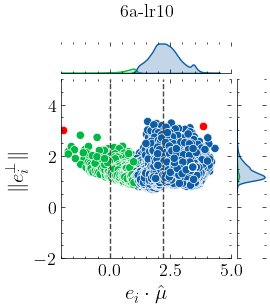

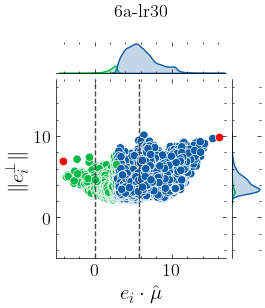

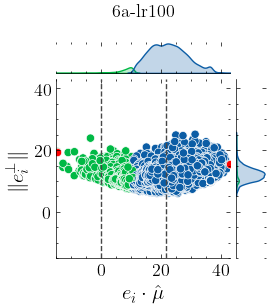

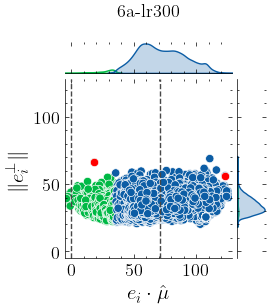

In [39]:
# model_size = 8

for k in KEYS[9:13]:
    plot_jointplot(
        _data=df[k], 
        _x=r'$e_i \cdot \hat \mu$', 
        _y=r'$\| e_i^\perp \|$', 
        _xlim=limnorm, 
        _ylim=limnorm, 
        _munorm=np.sqrt(musq[k]),
        height=3,
        title=nicekey(k),
    )

### d. correlation

In [40]:
df[KEY0].corr()

,$e_i \cdot \hat \mu$,$\| e_i^\parallel \|$,$\| e_i^\perp \|$,below,$\| e_i \|$,$\| e_i^\star \|$
$e_i \cdot \hat \mu$,1.000000,0.997879,0.417168,-0.495275,0.977193,0.268472
$\| e_i^\parallel \|$,0.997879,1.000000,0.423851,-0.489168,0.981516,0.282400
$\| e_i^\perp \|$,0.417168,0.423851,1.000000,-0.035061,0.578384,0.790227
below,-0.495275,-0.489168,-0.035061,1.000000,-0.414473,0.339477
$\| e_i \|$,0.977193,0.981516,0.578384,-0.414473,1.000000,0.433932
$\| e_i^\star \|$,0.268472,0.282400,0.790227,0.339477,0.433932,1.000000


In [41]:
float(np.corrcoef(dotshat[KEY0], E_perp_norm[KEY0])[0, 1])

0.41716833725435276

In [42]:
df[KEY0][df[KEY0][r'$e_i \cdot \hat \mu$'] < np.sqrt(musq[KEY0])].corr() 

,$e_i \cdot \hat \mu$,$\| e_i^\parallel \|$,$\| e_i^\perp \|$,below,$\| e_i \|$,$\| e_i^\star \|$
$e_i \cdot \hat \mu$,1.000000,0.989123,-0.025330,-0.738288,0.928157,-0.792226
$\| e_i^\parallel \|$,0.989123,1.000000,-0.004238,-0.738231,0.949114,-0.766931
$\| e_i^\perp \|$,-0.025330,-0.004238,1.000000,0.118637,0.282405,0.609174
below,-0.738288,-0.738231,0.118637,1.000000,-0.640346,0.698232
$\| e_i \|$,0.928157,0.949114,0.282405,-0.640346,1.000000,-0.542131
$\| e_i^\star \|$,-0.792226,-0.766931,0.609174,0.698232,-0.542131,1.000000


In [43]:
df[KEY0][df[KEY0][r'$e_i \cdot \hat \mu$'] >= np.sqrt(musq[KEY0])].corr() 

,$e_i \cdot \hat \mu$,$\| e_i^\parallel \|$,$\| e_i^\perp \|$,below,$\| e_i \|$,$\| e_i^\star \|$
$e_i \cdot \hat \mu$,1.000000,1.000000,0.319159,NaN,0.960297,0.753041
$\| e_i^\parallel \|$,1.000000,1.000000,0.319159,NaN,0.960297,0.753041
$\| e_i^\perp \|$,0.319159,0.319159,1.000000,NaN,0.567933,0.853598
below,NaN,NaN,NaN,NaN,NaN,NaN
$\| e_i \|$,0.960297,0.960297,0.567933,NaN,1.000000,0.903443
$\| e_i^\star \|$,0.753041,0.753041,0.853598,NaN,0.903443,1.000000


In [44]:
for k in KEYS:
    print(k, float(np.corrcoef(dotshat[k], E_perp_norm[k])[0, 1]))

('4', 'A', 'lr10-') 0.41716833725435276
('4', 'a', 'lr3-') 0.22507669426337013
('4', 'a', 'lr10-') 0.15750919978568648
('4', 'a', 'lr30-') 0.32806982367403864
('4', 'a', 'lr100-') 0.5416742902685442
('4', 'a', 'lr300-') 0.543007408948269
('4', 'a', 'lr1000-') 0.28098588838356364
('4', 'a', 'lr3000-') 0.36428214989788693
('6', 'a', 'lr3-') 0.07840280280966301
('6', 'a', 'lr10-') 0.29444541533678603
('6', 'a', 'lr30-') 0.5515061938249745
('6', 'a', 'lr100-') 0.41340284761397006
('6', 'a', 'lr300-') 0.41483288146475805
('6', 'a', 'lr1000-') 0.5033917338546886
('6', 'a', 'lr3000-') 0.40846328121404724
('8', 'a', 'lr3-') 0.1391203481969845
('8', 'a', 'lr10-') 0.47067517423547056
('8', 'a', 'lr30-') 0.4536254835339436
('8', 'a', 'lr100-') 0.5975483983960649
('8', 'a', 'lr300-') 0.6017675216563839
('8', 'a', 'lr1000-') 0.5781739737306698
('8', 'a', 'lr3000-') 0.3883746792637164
('A', 'a', 'lr3-') 0.06429731486287282
('A', 'a', 'lr10-') 0.35572799749772216
('A', 'a', 'lr30-') 0.446308121030632

### e. max - min

In [45]:
np.max(dotshat[KEY0])

np.float32(4.316875)

In [46]:
np.min(dotshat[KEY0])

np.float32(-1.3172606)

In [47]:
maxmin = (np.max(dotshat[KEY0]) + np.min(dotshat[KEY0])) / 2
maxmin

np.float32(1.4998071)

#### dotshat_maxmin

In [48]:
dotshat_maxmin = dotshat[KEY0] - maxmin

In [49]:
np.max(dotshat_maxmin)

np.float32(2.8170679)

In [50]:
np.min(dotshat_maxmin)

np.float32(-2.8170676)

#### dotshat_centered

In [51]:
dotshat_centered = dotshat[KEY0] - np.sqrt(musq[KEY0])

In [52]:
np.max(dotshat_centered)

np.float32(2.1046169)

In [53]:
np.min(dotshat_centered)

np.float32(-3.5295186)

# 3. Analysis: Embedding Norm Distribution

In [54]:
E[KEY0].shape

(50304, 224)

In [55]:
Estar = {k: E[k] - mu[k].T for k in KEYS}
Estar[KEY0].shape

(50304, 224)

In [56]:
norm_E = {k: np.linalg.norm(E[k], axis=1, keepdims=False) for k in KEYS}
norm_E[KEY0].shape

(50304,)

In [57]:
norm_Estar = {k: np.linalg.norm(Estar[k], axis=1, keepdims=False) for k in KEYS}
norm_Estar[KEY0].shape

(50304,)

In [58]:
norm_mu = {k: np.linalg.norm(mu[k]) for k in KEYS}
norm_mu[KEY0]

np.float32(2.212258)

In [59]:
norm_ratio = {k: norm_Estar[k] / norm_E[k] for k in KEYS}
norm_ratio[KEY0].shape

(50304,)

In [60]:
norm_ratio_max = {k: float(np.max(norm_Estar[k]) / np.max(norm_E[k])) for k in KEYS}
norm_ratio_max

{('4', 'A', 'lr10-'): 0.8640042543411255,
 ('4', 'a', 'lr3-'): 1.1686785221099854,
 ('4', 'a', 'lr10-'): 0.854701042175293,
 ('4', 'a', 'lr30-'): 0.8790827393531799,
 ('4', 'a', 'lr100-'): 0.8091112971305847,
 ('4', 'a', 'lr300-'): 0.7795553803443909,
 ('4', 'a', 'lr1000-'): 0.6319960355758667,
 ('4', 'a', 'lr3000-'): 0.716056764125824,
 ('6', 'a', 'lr3-'): 1.147640585899353,
 ('6', 'a', 'lr10-'): 1.0195112228393555,
 ('6', 'a', 'lr30-'): 0.7569611072540283,
 ('6', 'a', 'lr100-'): 0.9017326831817627,
 ('6', 'a', 'lr300-'): 0.6238654851913452,
 ('6', 'a', 'lr1000-'): 0.7140173316001892,
 ('6', 'a', 'lr3000-'): 0.7870280742645264,
 ('8', 'a', 'lr3-'): 1.295312523841858,
 ('8', 'a', 'lr10-'): 0.8917801976203918,
 ('8', 'a', 'lr30-'): 0.8998100161552429,
 ('8', 'a', 'lr100-'): 0.8252252340316772,
 ('8', 'a', 'lr300-'): 0.732255220413208,
 ('8', 'a', 'lr1000-'): 0.7415053248405457,
 ('8', 'a', 'lr3000-'): 0.7251666188240051,
 ('A', 'a', 'lr3-'): 1.167507529258728,
 ('A', 'a', 'lr10-'): 0.85

In [61]:
norm_df = {k: pd.DataFrame({'E': norm_E[k], 'Estar': norm_Estar[k], 'model_size': k[0], 'lr': int(k[2][2:][:-1])}) for k in KEYS}
norm_df[KEY0].describe()

,E,Estar,lr
count,50304.000000,50304.000000,50304.0
mean,2.435182,1.167866,10.0
std,0.698566,0.400187,0.0
min,0.901311,0.435747,10.0
25%,1.942186,0.874428,10.0
50%,2.350407,1.086034,10.0
75%,2.897092,1.370839,10.0
max,4.758293,4.111186,10.0


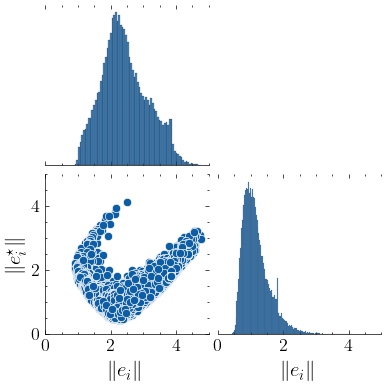

In [62]:
p = sns.pairplot(norm_df[KEY0][['E', 'Estar']], corner=True, height=2)
_ = p.set(xlim=(0,5), ylim=(0,5), xlabel=r'$\| e_i \|$', ylabel=r'$\| e_i^\star \|$')

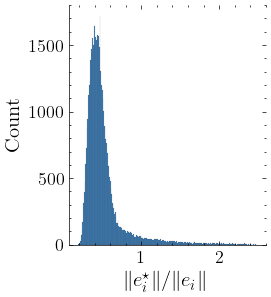

In [63]:
p = sns.displot(norm_ratio[KEY0], height=3)
_ = p.set(xlabel=r'$\| e_i^\star \| / \| e_i \|$')

In [64]:
def ratio(_input):
    _Estar, _E = _input
    return _Estar / _E

df_all = pd.concat(list(norm_df.values()), ignore_index=True)
df_all['Estar/E'] = df_all[['Estar', 'E']].apply(lambda x: ratio(x), axis=1) 
df_all

,E,Estar,model_size,lr,Estar/E
0,1.341256,2.603530,4,10,1.941114
1,1.578883,2.279780,4,10,1.443920
2,1.617816,1.175507,4,10,0.726601
3,1.711457,1.153476,4,10,0.673973
4,1.543737,1.565484,4,10,1.014087
...,...,...,...,...,...
1810939,627.424927,248.471481,C,3000,0.396018
1810940,627.427551,248.470779,C,3000,0.396015
1810941,627.427979,248.467422,C,3000,0.396009
1810942,627.432129,248.472626,C,3000,0.396015


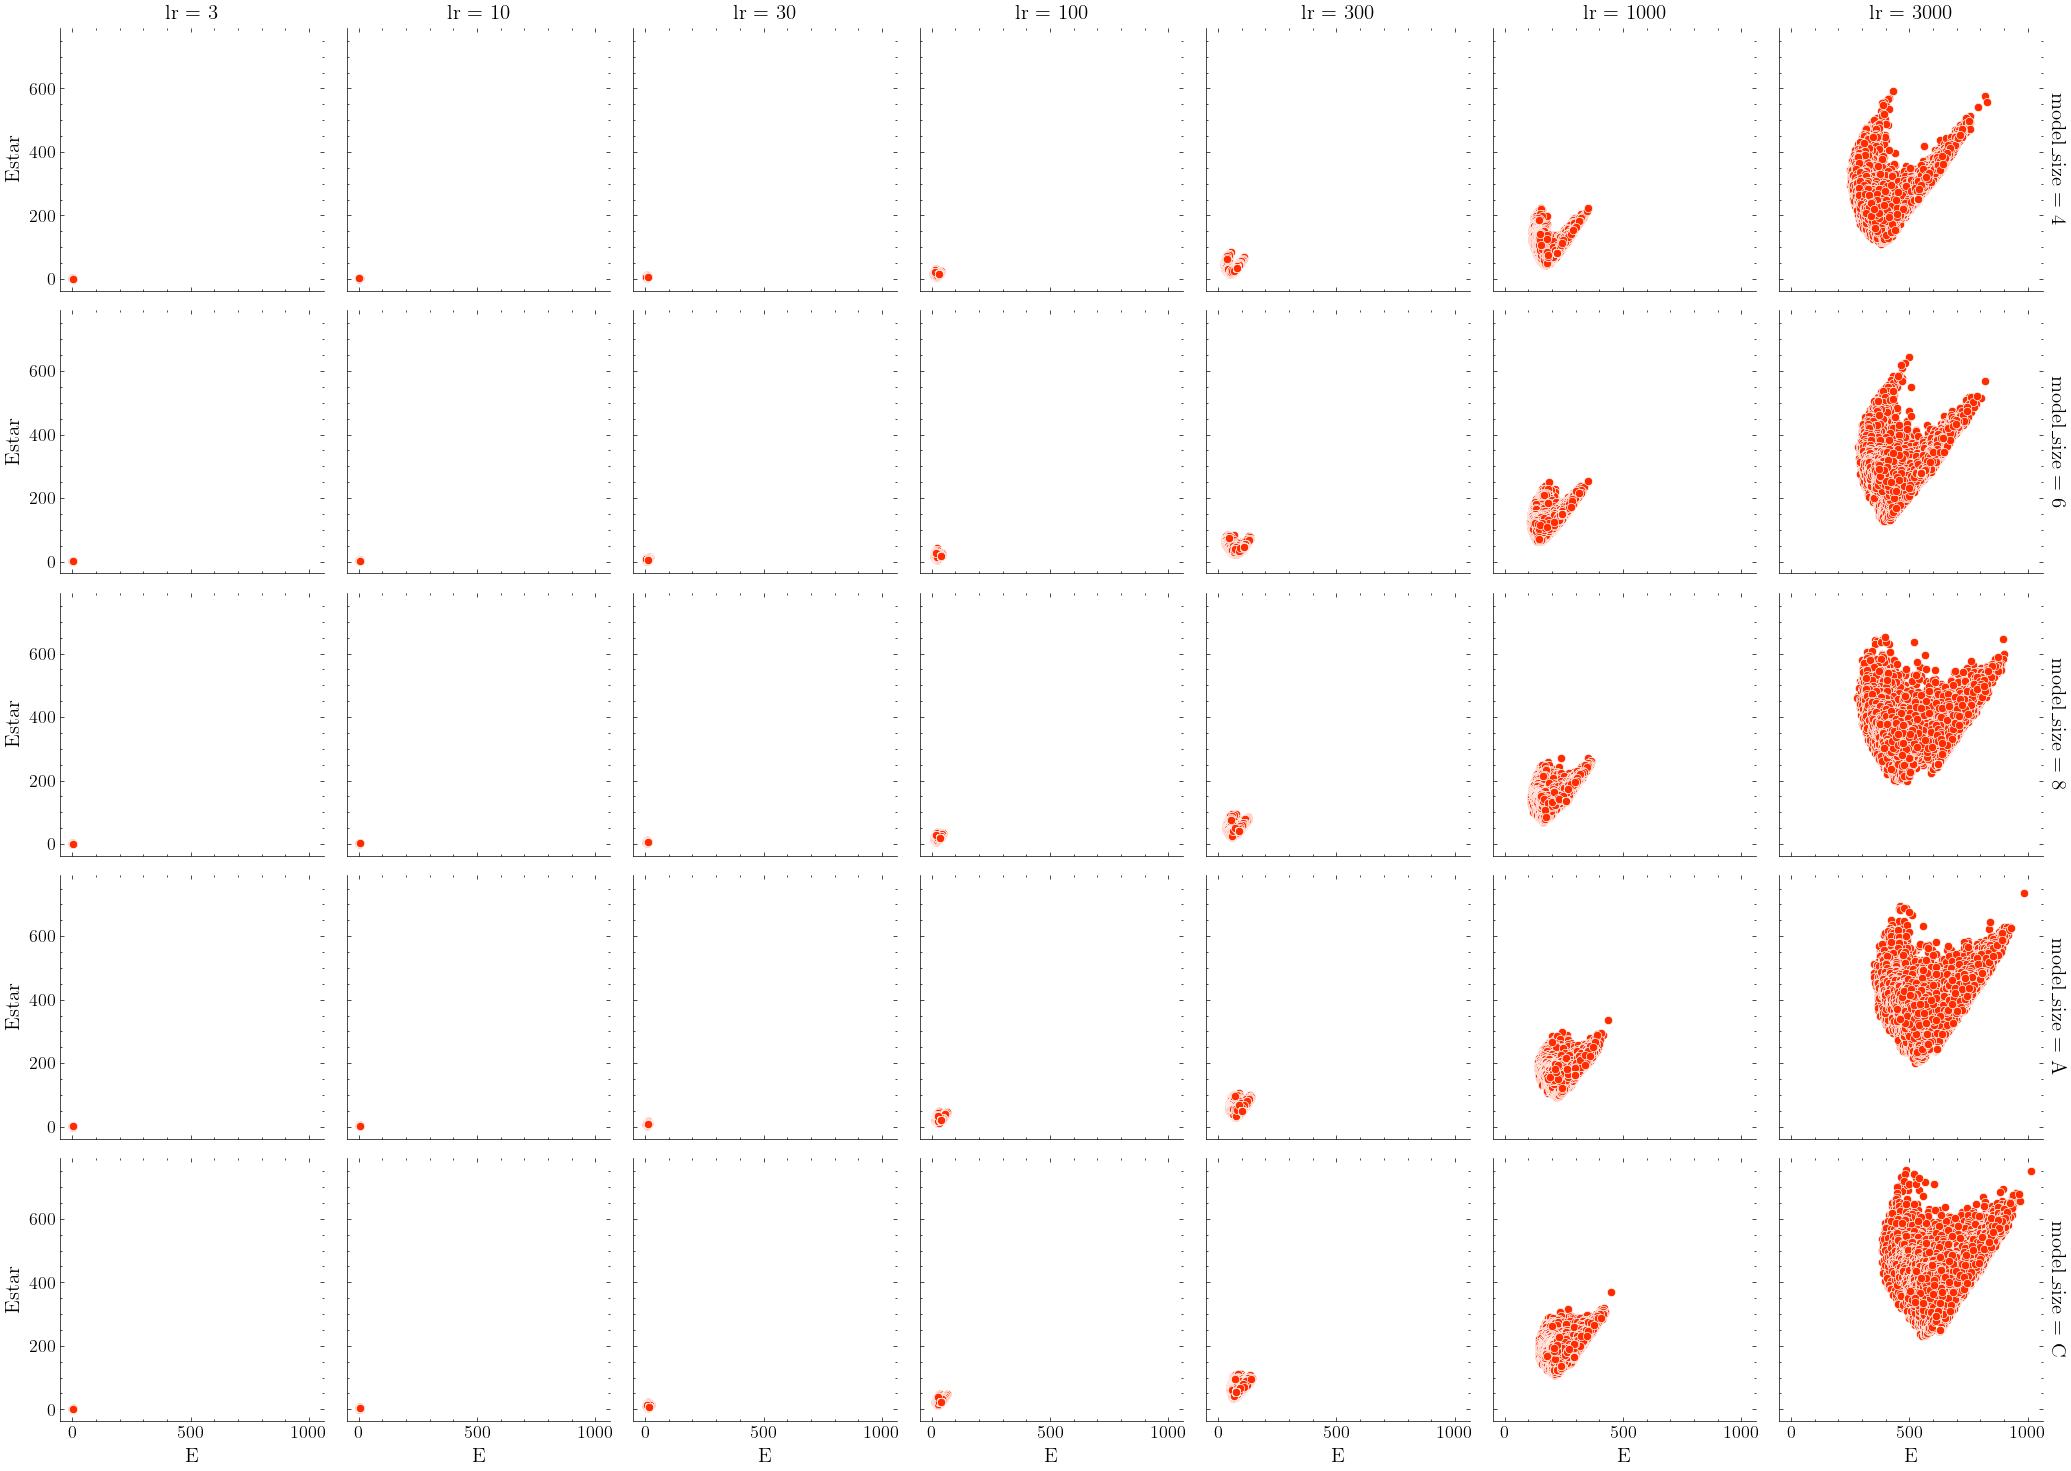

In [65]:
CLR = '#FF2C00'
g = sns.FacetGrid(df_all, row="model_size", col="lr", margin_titles=True)
_ = g.map(sns.scatterplot, "E", "Estar", color=CLR)

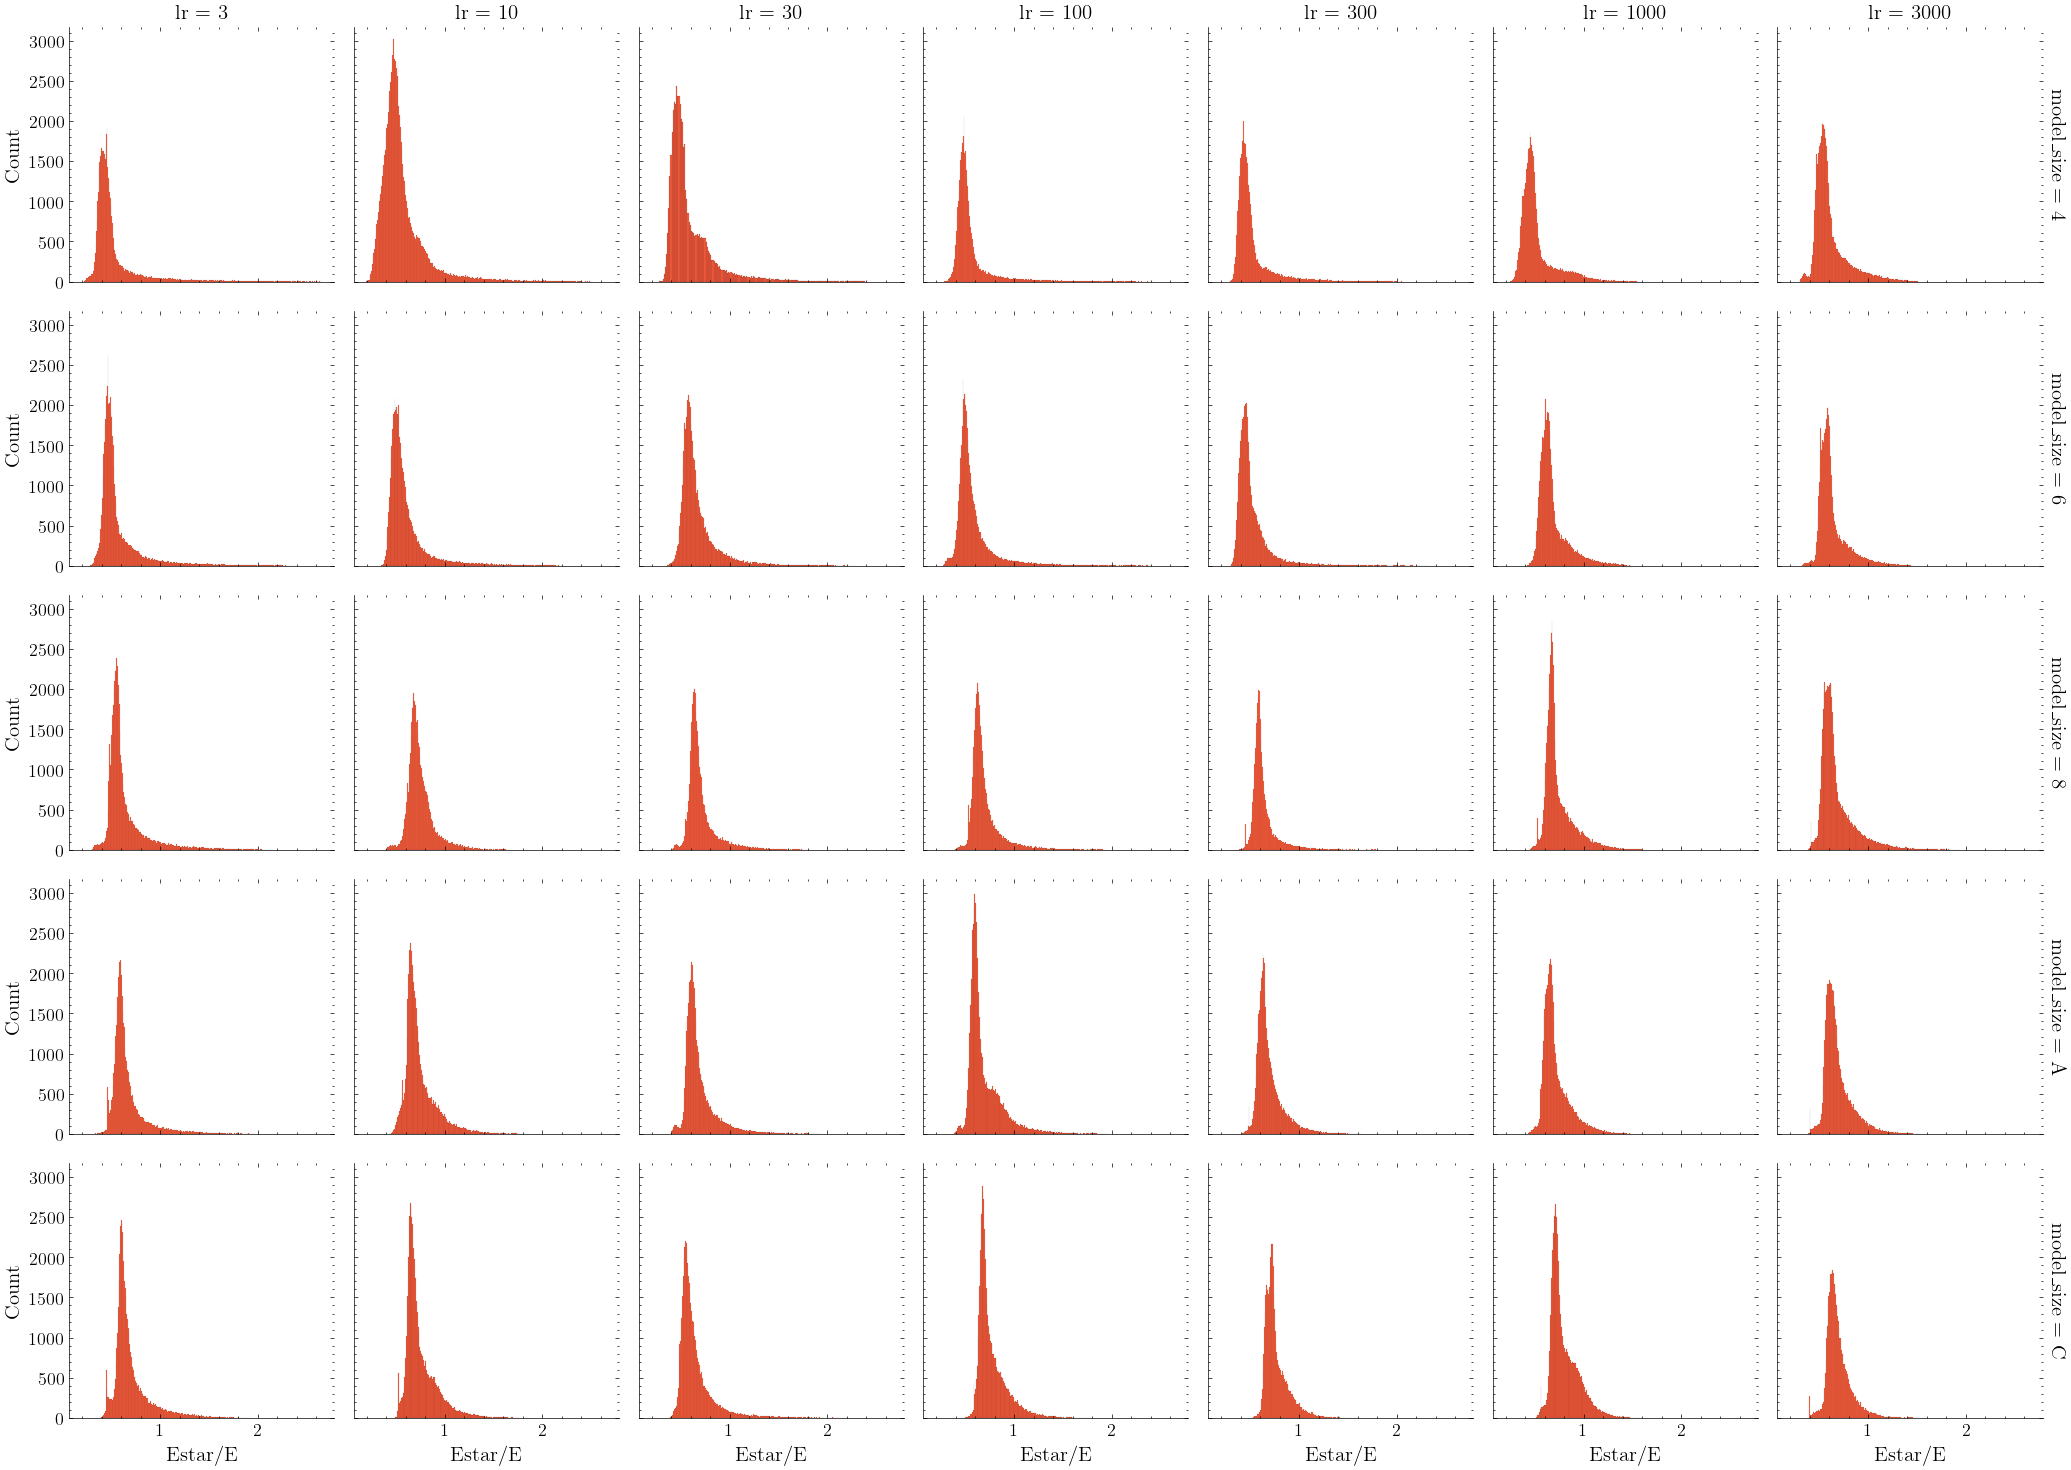

In [66]:
g = sns.FacetGrid(df_all, row="model_size", col="lr", margin_titles=True)
_ = g.map(sns.histplot, "Estar/E", color=CLR)